# Отчет к Лабораторной работе №3 "Численное интегрирование"

Шуман Владислав Олегович

3 курс, 4 группа

Вариант 1.2

[Github](https://github.com/UladzislauShuman/university_homework/tree/main/famcs_homework/numerical_methods/6sem/lab3)

Время последнего изменения: 03.05.2026

Часть из электронных конспектов, которую я использовал: 
- [тут](../../теория/лаб3)
- [или тут (Github) в папке лаб3](https://github.com/UladzislauShuman/university_homework/tree/main/famcs_homework/numerical_methods/6sem/%D1%82%D0%B5%D0%BE%D1%80%D0%B8%D1%8F)


# Условие

с полным условием можно ознакомиться
- [тут](famcs_homework/numerical_methods/6sem/lab3/условие/условие.pdf)
- [или тут (Github)](https://github.com/UladzislauShuman/university_homework/tree/main/famcs_homework/numerical_methods/6sem/lab3/%D1%83%D1%81%D0%BB%D0%BE%D0%B2%D0%B8%D0%B5)

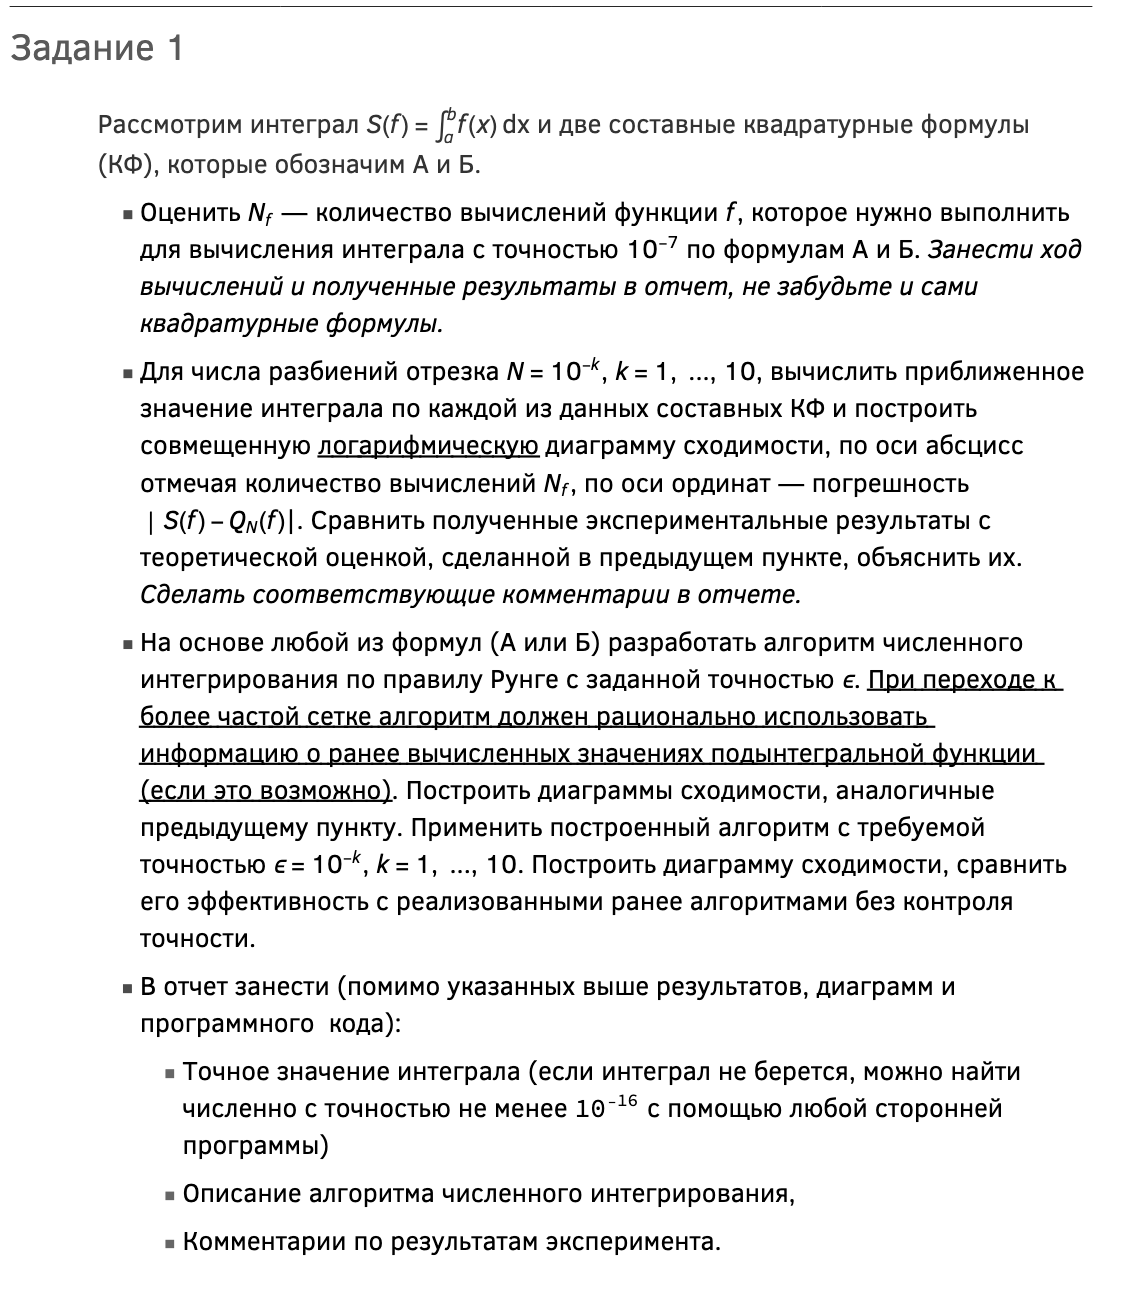

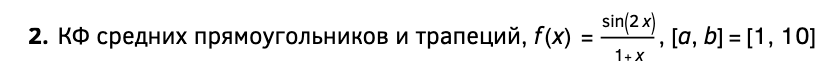

# Решение

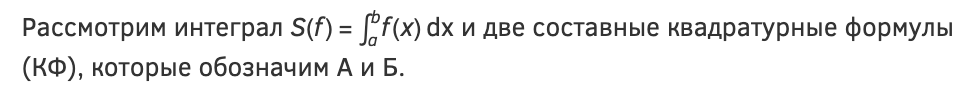

# Пункт 1

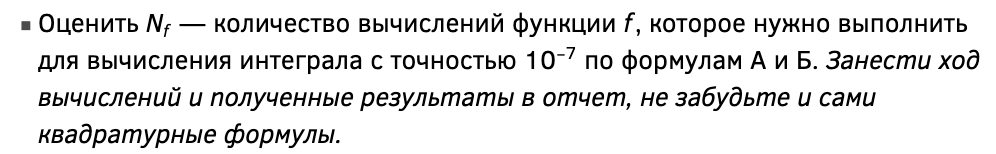

## составные КФ Средних прямоугольников

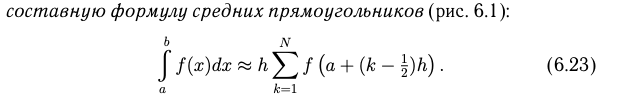

## составные КФ Трапеций

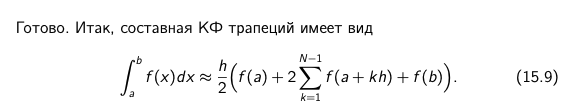

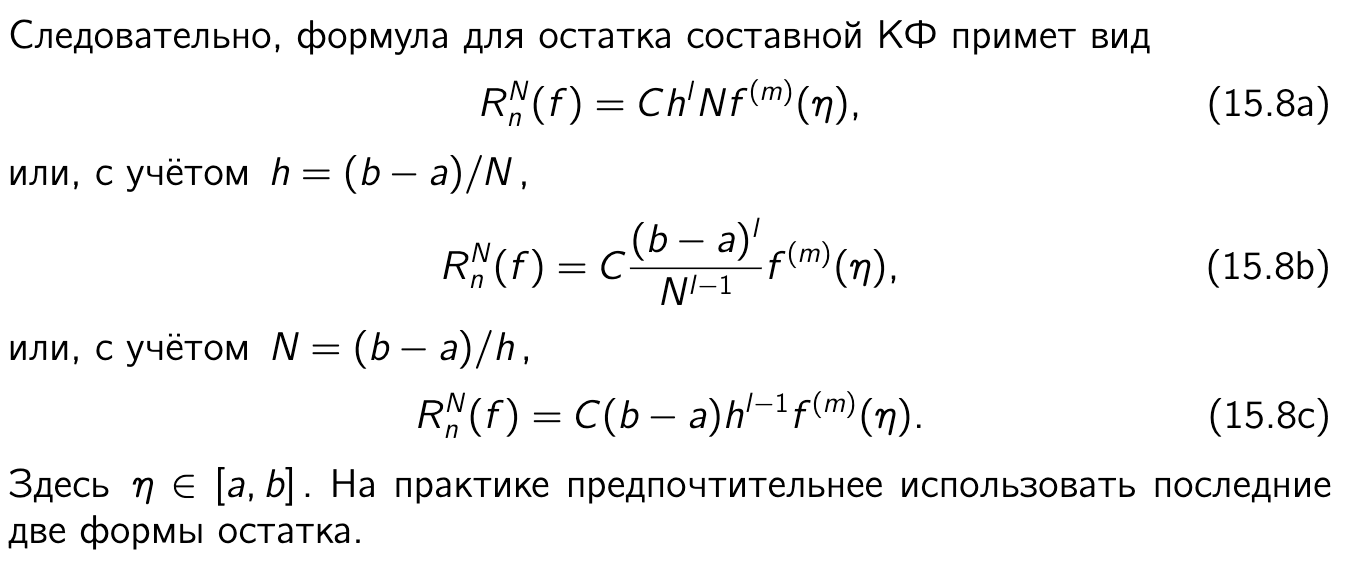

как получить постоянные из формулы

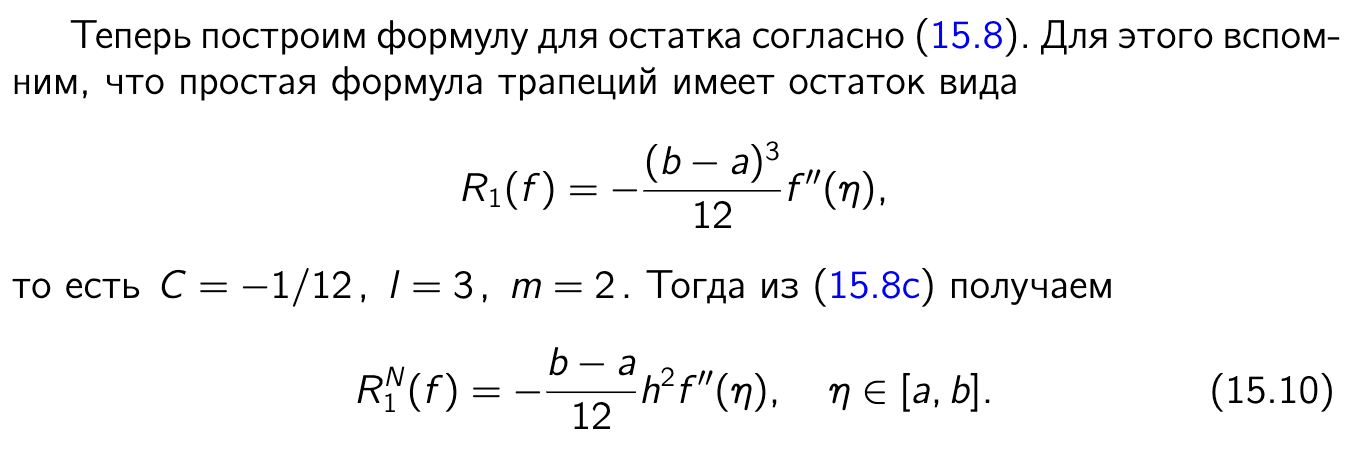

остаток для средних прямоугольников для простейших интерполяционных КФ

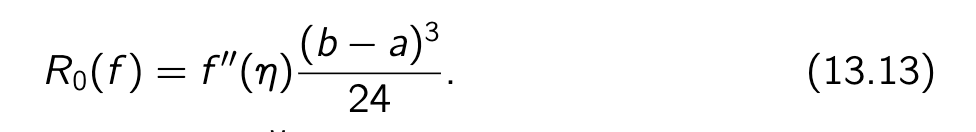

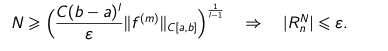

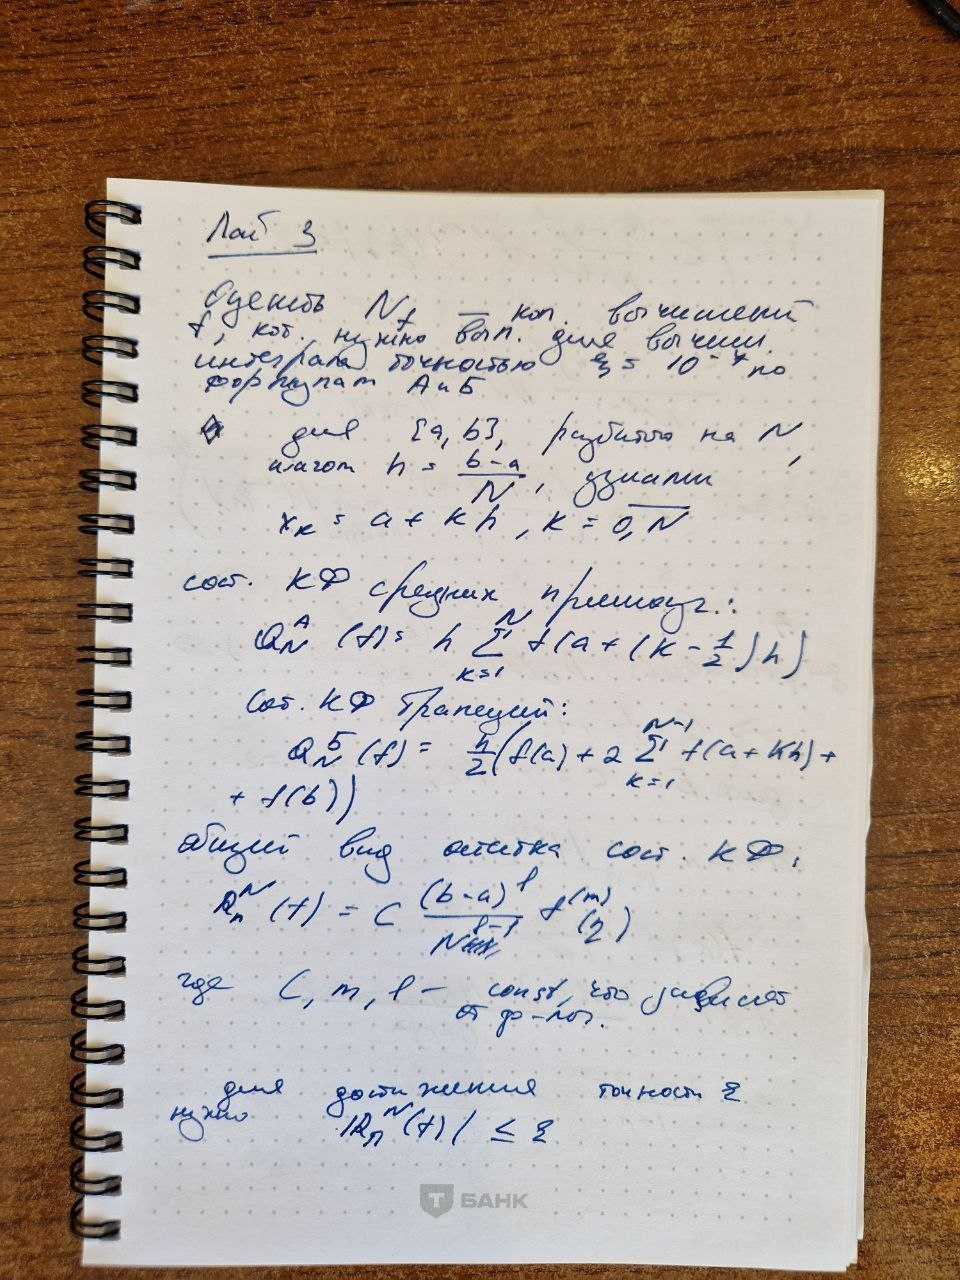

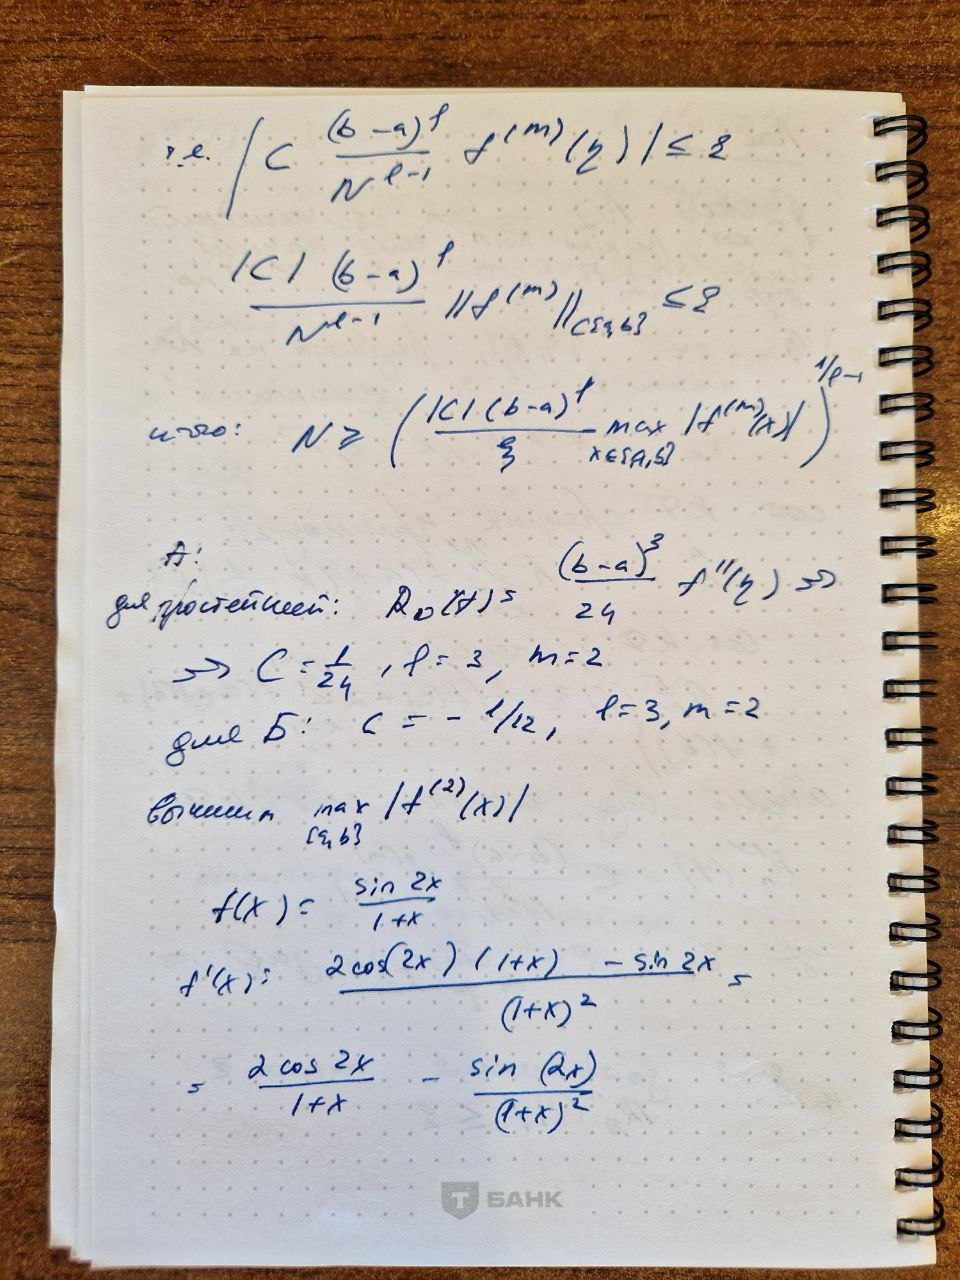

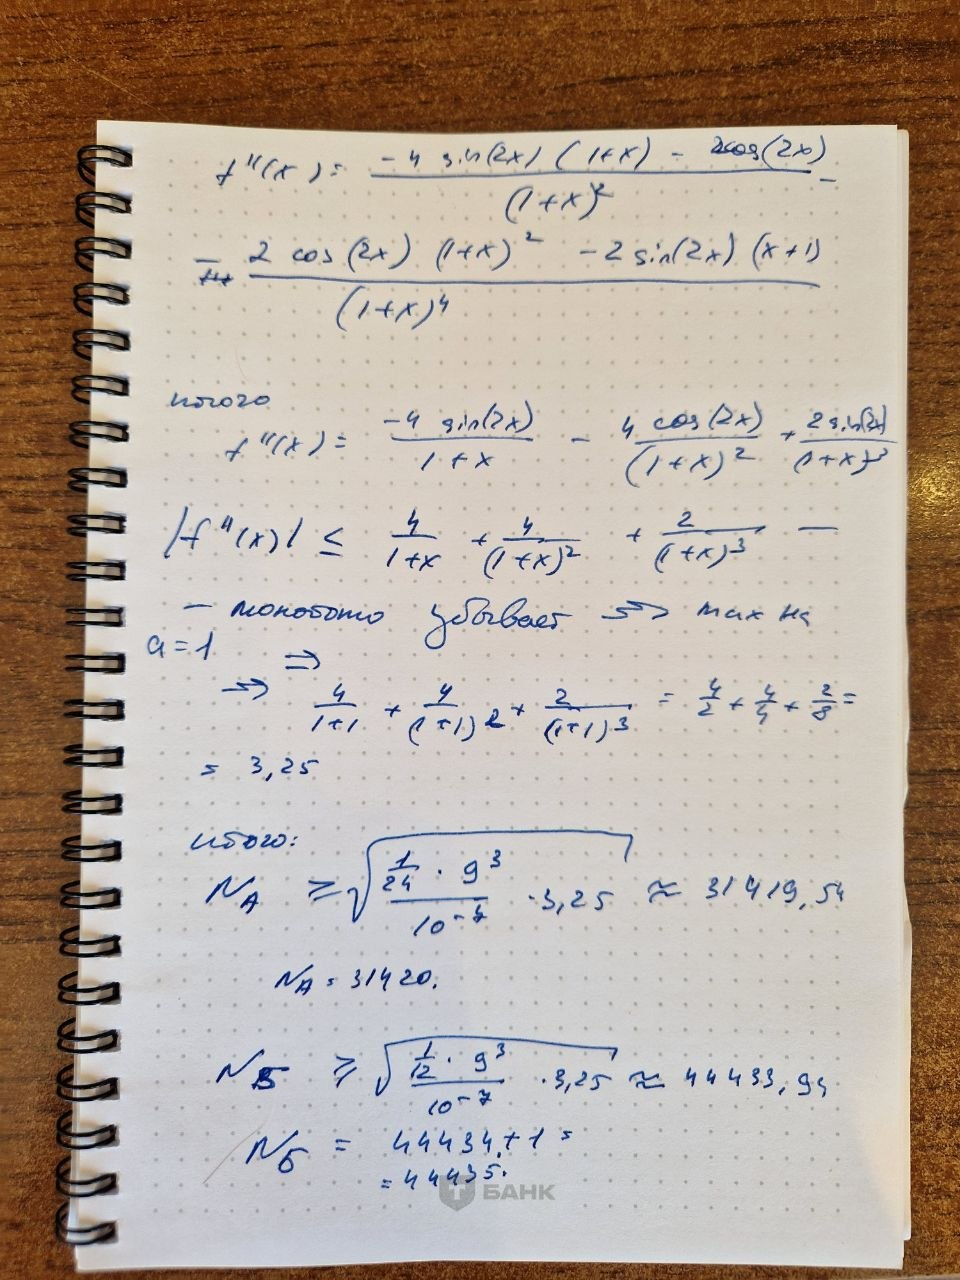

Итого $N_{A} = 31420$ и $N_{Б} = 44435$

# Пункт 2

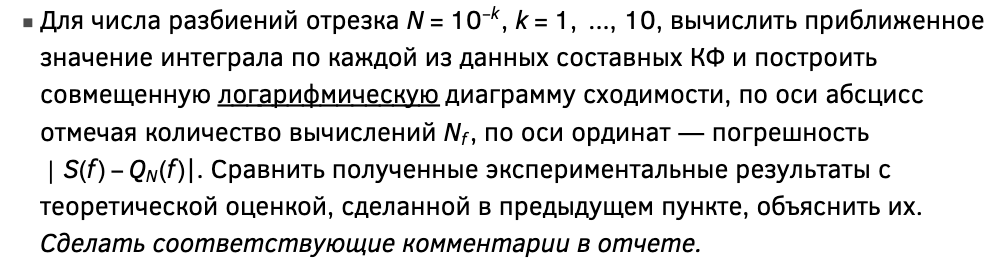

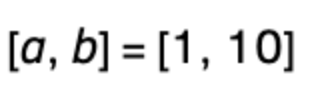

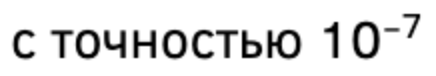

In [58]:
# входные параметры 
a, b = 1.0, 10.0 # отрезок [a,b]
eps = 1e-7 #погрешность

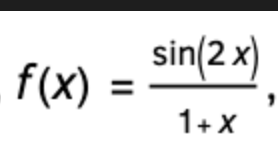

In [60]:
import numpy as np

# функция f
def f(x):
    return np.sin(2 * x) / (1 + x)

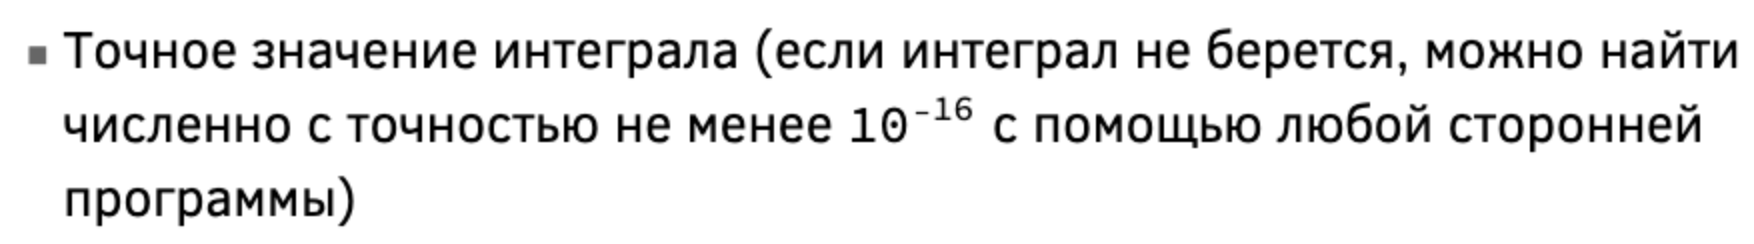

In [61]:
# "эталонное" значение,  
from scipy.integrate import quad

S_f, _ = quad(f, a, b, epsabs=1e-16)

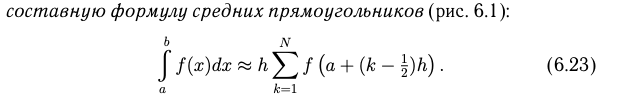

In [62]:
def composite_formula_of_medium_rectangles(a, b, N, chunk_size=10**7):
    h = (b - a) / N # шаг
    total_sum = 0.0 # тут копить будем 
    for k in range(1, N + 1, chunk_size):
        current_n = min(chunk_size, N + 1 - k) # либо размер шага, либо если он меньше, то N - i
        indices = np.arange(k, k + current_n) # индексы на текущей итерации
        x_mid = a + (indices - 0.5) * h # иксы на текущей итерации
        total_sum += np.sum(f(x_mid)) # добавить часть суммы для текущей итерации
    return h * total_sum, N

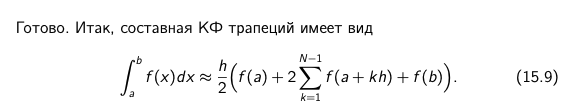

In [63]:
def composite_formula_of_trapezoids(a, b, N, chunk_size=10**7):
    h = (b - a) / N
    internal_points_sum = 0.0
    
    # 2 * СУММА(...)
    for k in range(1, N, chunk_size):
        current_n = min(chunk_size, N - k)
        indices = np.arange(k, k + current_n)
        x_k = a + indices * h
        internal_points_sum += np.sum(f(x_k))
    
    # итог
    integral = (h / 2) * (f(a) + f(b) + 2 * internal_points_sum)
    return integral, N + 1

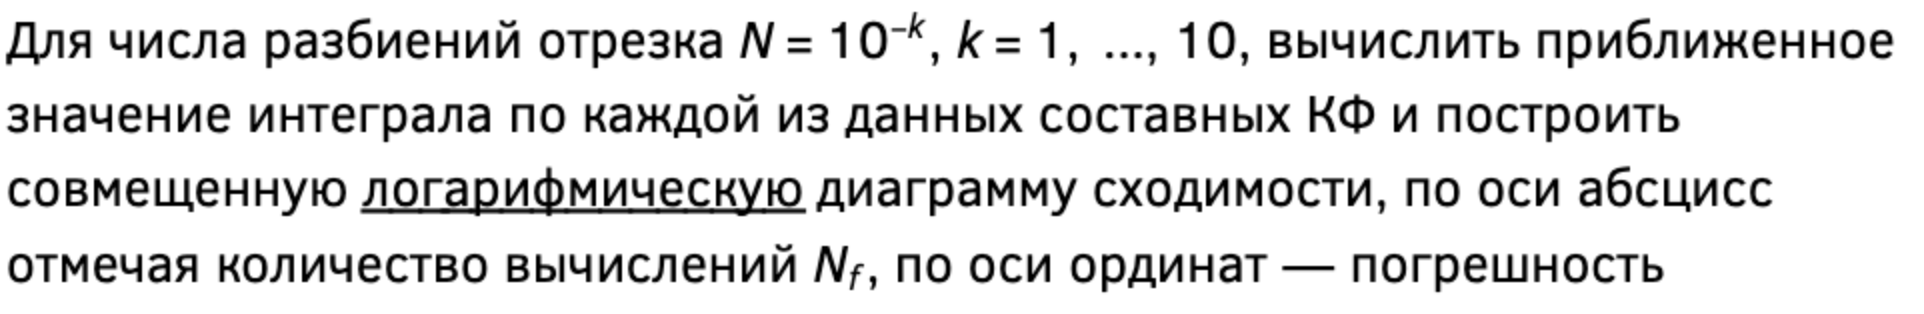

In [ ]:
import time

k_values = np.arange(1, 11) # k 1 -- 10
results = [] # результаты

print(f"{'k':<3} | {'N':<11} | {'метод':<15} | {'погрешность':<12} | {'время (в секундах)':<10}")
print("-" * 65)

for k in k_values:
    N = 10**k
    
    # средние прямоугльники
    start_medium_rectangles = time.time()
    val_medium_rectangles, Nf_medium_rectangles = composite_formula_of_medium_rectangles(a, b, N)
    error_medium_rectangles = abs(S_f - val_medium_rectangles)
    t_medium_rectangles = time.time() - start_medium_rectangles
    
    # трапеции
    start_trapezoids = time.time()
    val_trapezoids, Nf_trapezoids = composite_formula_of_trapezoids(a, b, N)
    error_trapezoids = abs(S_f - val_trapezoids)
    t_trapezoids = time.time() - start_trapezoids
    
    results.append((Nf_medium_rectangles, error_medium_rectangles, Nf_trapezoids, error_trapezoids))
    
    print(f"{k:<3} | 10^{k:<8} | прямоугольники | {error_medium_rectangles:<12.2e} | {t_medium_rectangles:<10.2f}")
    print(f"{'':<3} | {'':<11} | трапеции       | {error_trapezoids:<12.2e} | {t_trapezoids:<10.2f}")
    print("-" * 65)


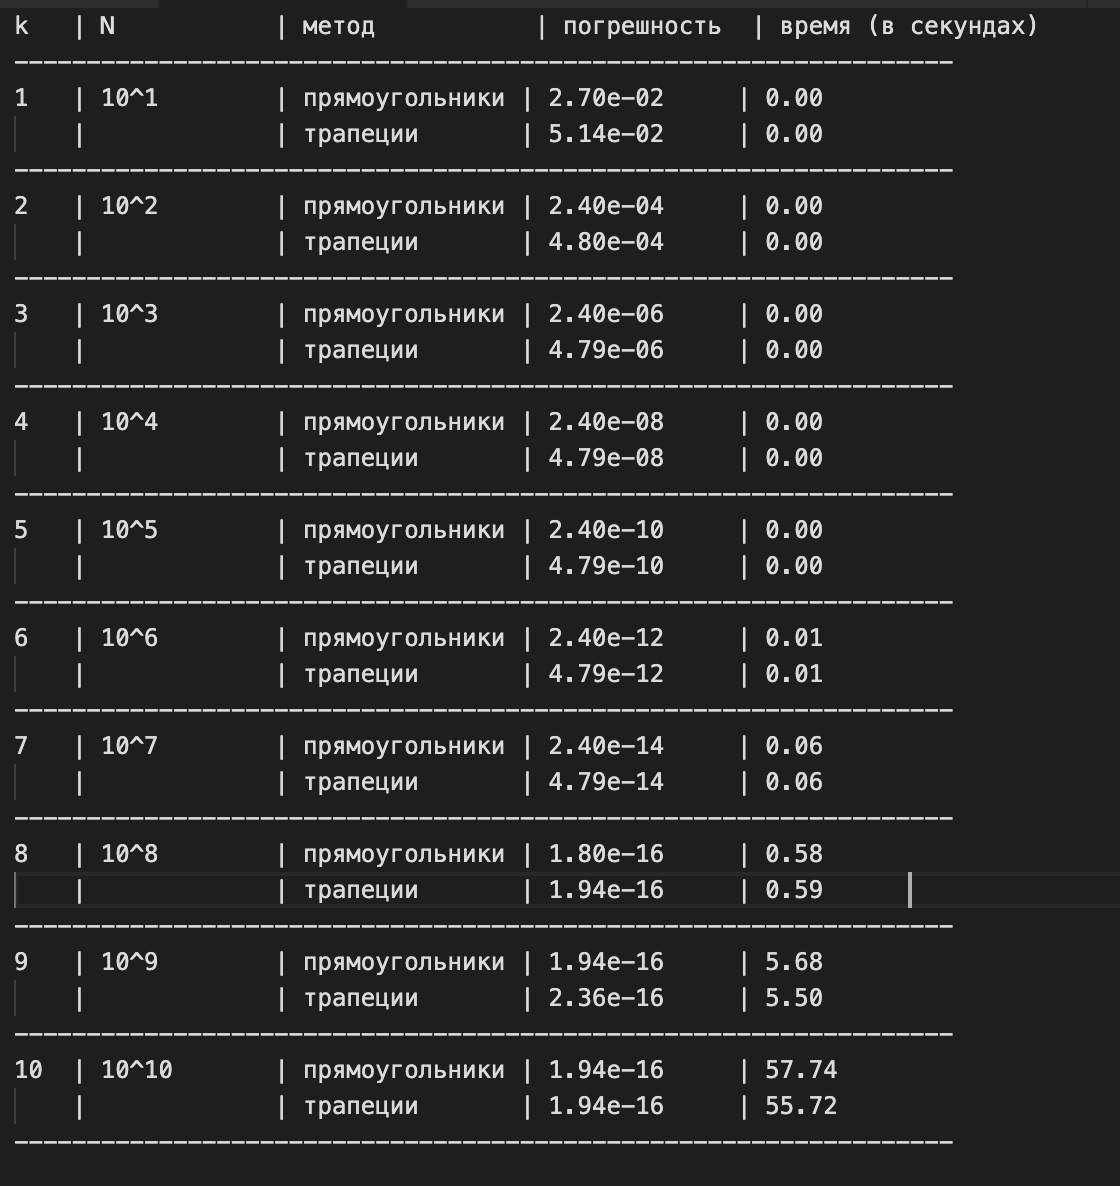

<>:17: SyntaxWarning: invalid escape sequence '\e'
<>:17: SyntaxWarning: invalid escape sequence '\e'
/var/folders/24/jr600lf178n120v25n50gtvh0000gn/T/ipykernel_88064/2328258788.py:17: SyntaxWarning: invalid escape sequence '\e'
  plt.axhline(y=eps, color='r', linestyle='--', label=f'$\epsilon = {eps}$')


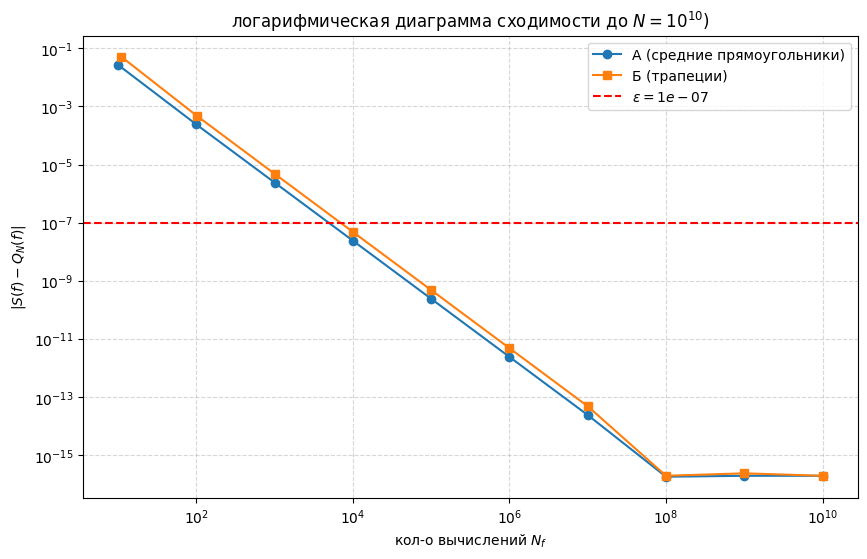

In [65]:
import matplotlib.pyplot as plt

# results.append((Nf_medium_rectangles, error_medium_rectangles, Nf_trapezoids, error_trapezoids))
(Nf_medium_rectangles_all, 
 error_medium_rectangles_all, 
 Nf_trapezoids_all, 
 error_trapezoids_all) = zip(*results)

plt.figure(figsize=(10, 6))


plt.loglog(Nf_medium_rectangles_all, error_medium_rectangles_all, 'o-',
           label='А (средние прямоугольники)')
plt.loglog(Nf_trapezoids_all, error_trapezoids_all, 's-', 
           label='Б (трапеции)')

plt.axhline(y=eps, color='r', linestyle='--', label=f'$\epsilon = {eps}$')

plt.title('логарифмическая диаграмма сходимости до $N=10^{10}$)')
plt.xlabel('кол-о вычислений $N_f$')
plt.ylabel('$|S(f) - Q_N(f)|$')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

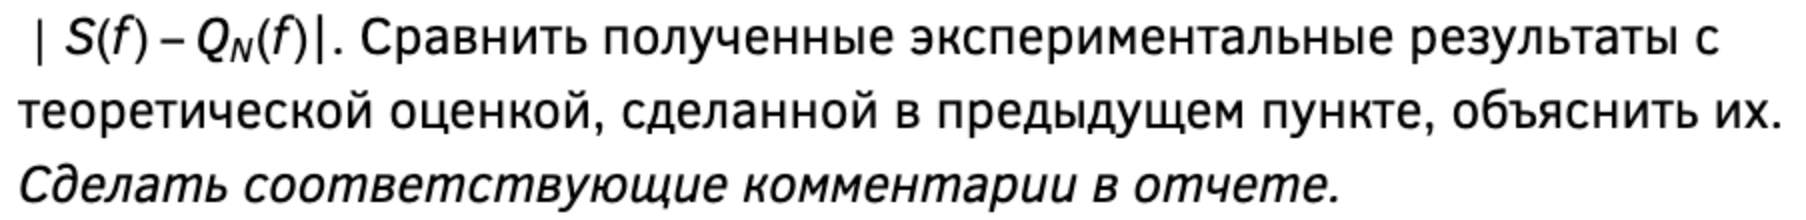

исходя из получившейся таблицы И графика, видно что погрешность у Прямоугольников в примерно 2 раза меньше, что похоже и на теоретический результат (константа $C_{прямоуг} = \frac{1}{24}$ в два раза меньше чем $C_{трап} = \frac{1}{12}$ )

так же, теоретически у нас получилось $N_{A} = 31420$ и $N_{Б} = 44435$, а практически $N_{практически} <= 10000$, то есть результаты отличаются в 3-4 раза. связанно это с тем, что теоретическая оценка, которую я использовал, является априорной и использует максимум производной на отрезке

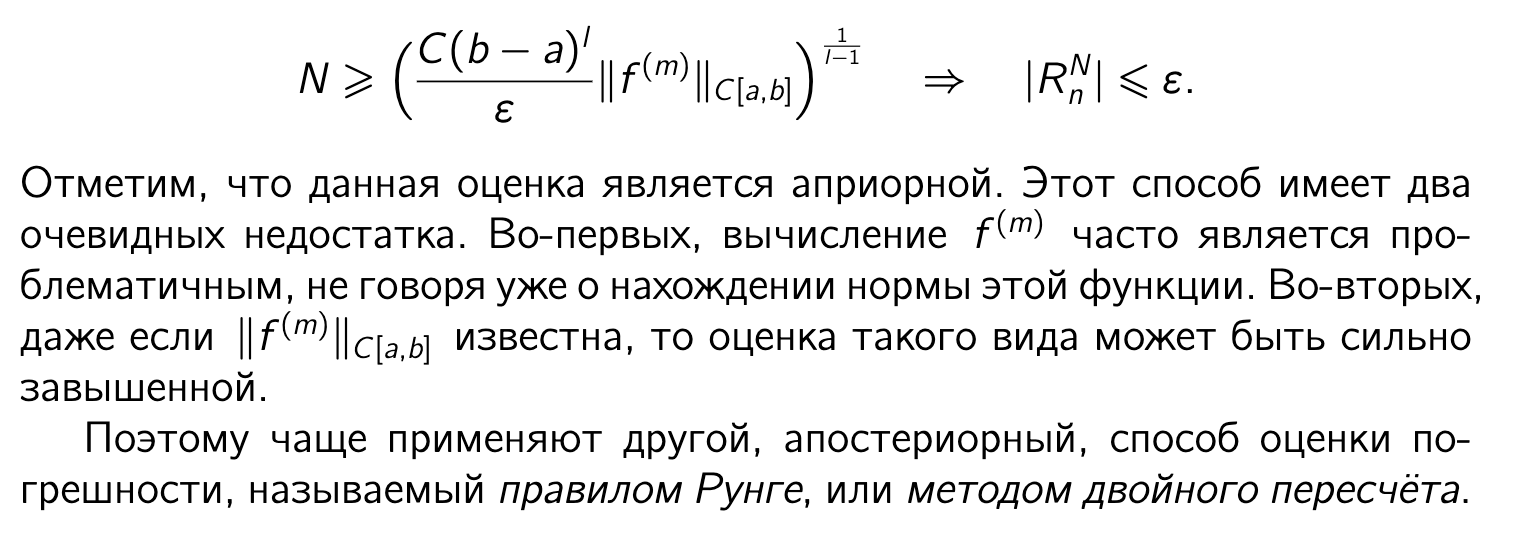

начиная с k = 8 погрешность как бы достигает "низа" (так как мы используем float64, то там ε ≈ 2.22 ⋅10−16)

# Пункт 3

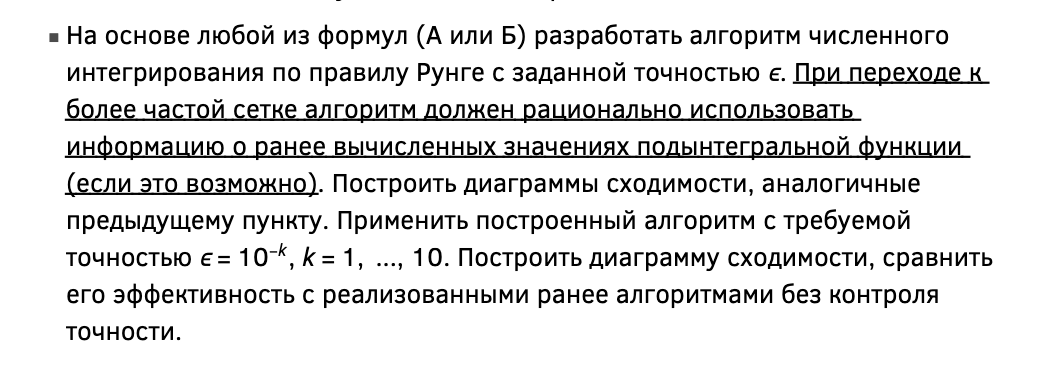

алгоритм из теории 

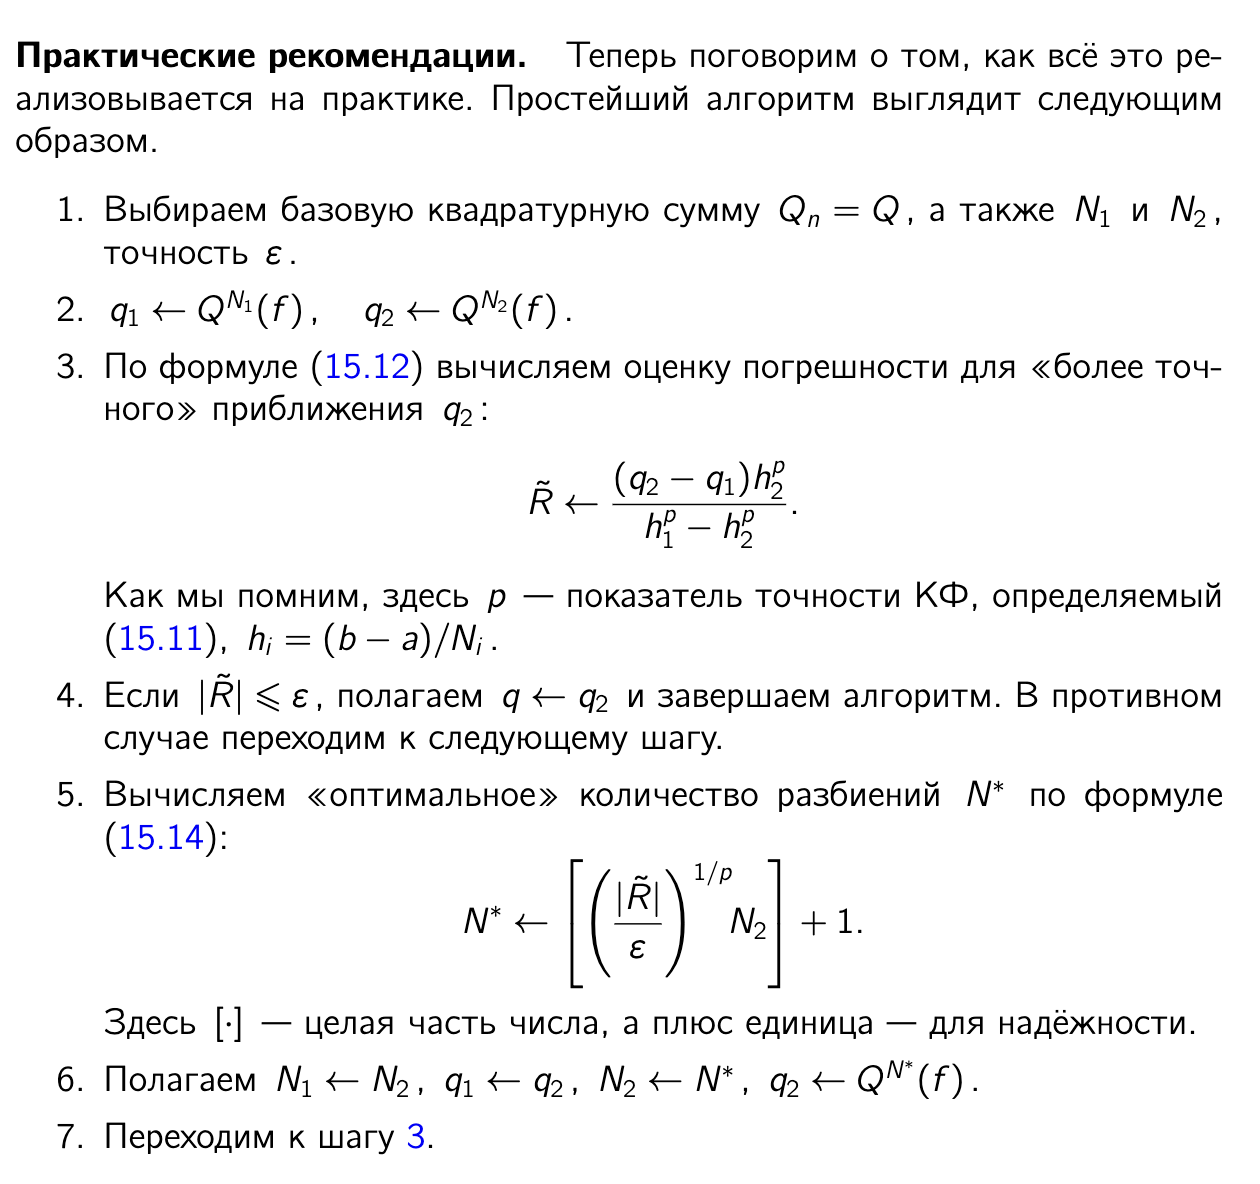

так как я могу выбрать любую формулу, то возьму Б(составную КФ трапеций)

чтобы рациально воспользоваться ранее вычисленными значениями, воспользуюсь следующим советом

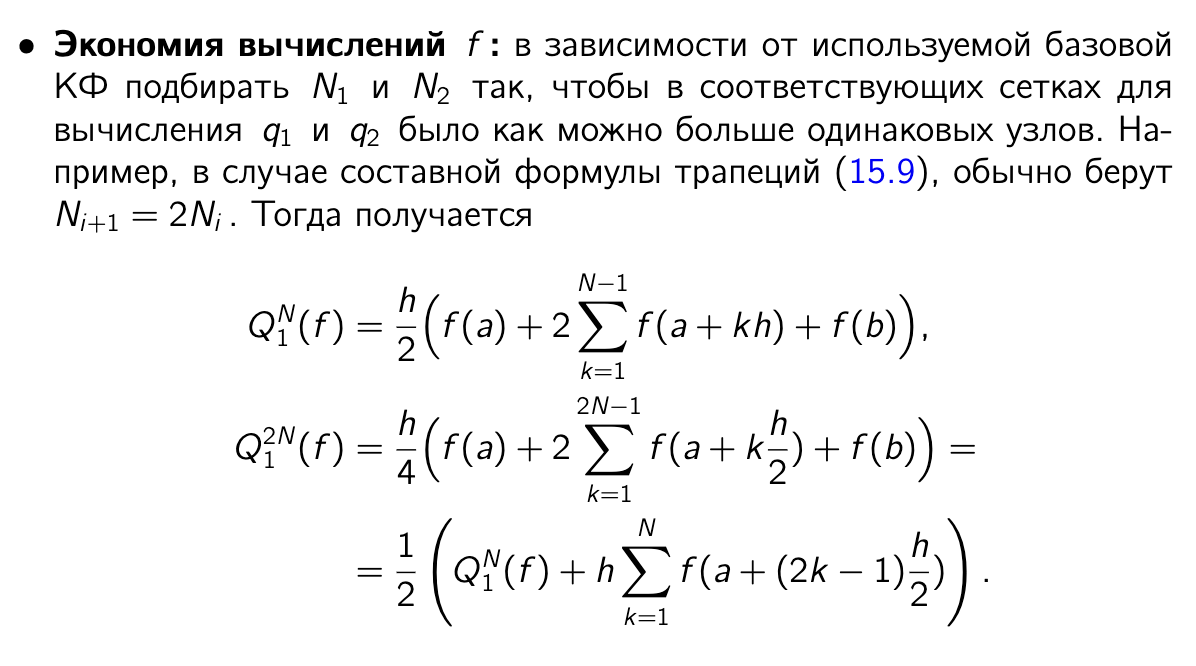

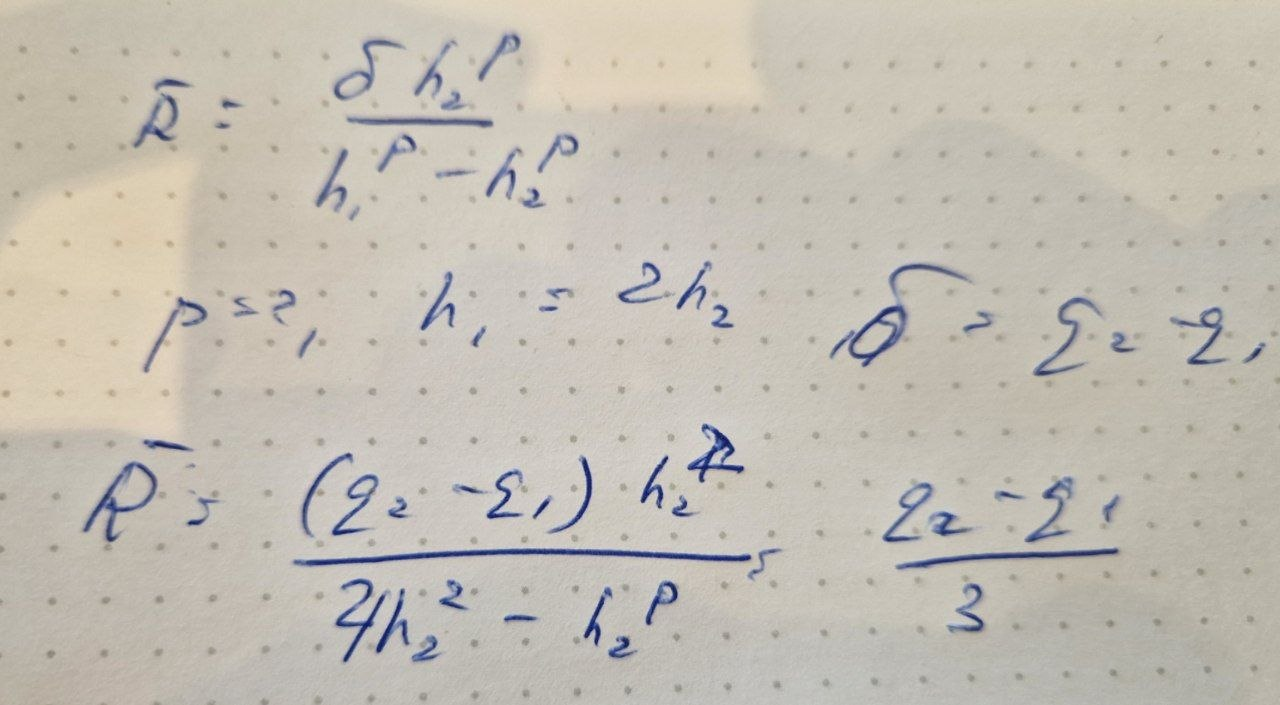

In [55]:
def runge_trapezoidal(a, b, target_precision):
    N = 1
    h = (b - a) / N
    integral_prev = (h / 2) * (f(a) + f(b)) # для первой итерации, N = 1
    evaluations_count = 2 # счетчик. сколько функций посчитано. чтобы вернуть N
    runge_error = float('inf') # хранить ошибку Рунге
    
   
    while runge_error > target_precision:
        N *= 2 # удваиваем
        h_new = (b - a) / N # h*
        
        # у нас остались старые узлы при N
        # надо посчитать новые при N* = 2N
        # а они расположены по a + (2 * 1 - 1)h_new, a + (2 * 2 - 1)*h_new, a + (2 * 3 - 1)*h_new ...
        indices = np.arange(1, N, 2) 
        x_new = a + indices * h_new
        
        sum_for_new = np.sum(f(x_new)) # сумма для новых
        evaluations_count += len(x_new) # счетчик прибавляем
        
        # пересчитываем по формуле
        integral_current = 0.5 * integral_prev + h_new * sum_for_new
        
        runge_error = abs(integral_current - integral_prev) / 3.0
        
        integral_prev = integral_current
    
    N_predicted = int(np.ceil((runge_error / target_precision)**(1/2) * N))
    return integral_current, evaluations_count, runge_error, N, N_predicted

results_runge = []

print(f"{'k':<3} | {'eps':<9} | {'N итоговое':<10} | {'N предск.':<10} | {'N_f (всего)':<11} | {'оценка ошибки':<12} | {'ошибка':<12}")
print("-" * 85)

for k in k_values:
    target_eps = 10.0**(-k) # eps для итерации
    val_runge, Nf_runge, err_runge_est, final_N, predicted_N = runge_trapezoidal(a, b, target_eps) # функцию применяем
    error = abs(S_f - val_runge) # ошибка
    results_runge.append((Nf_runge, error, target_eps)) # пополняем результаты
    print(f"{k:<3} | 10^{-k:<7} | {final_N:<10} | {predicted_N:<10} | {Nf_runge:<11} | {err_runge_est:<12.2e} | {error:<12.2e}")

k   | eps       | N итоговое | N предск.  | N_f (всего) | оценка ошибки | ошибка      
-------------------------------------------------------------------------------------
1   | 10^-1      | 4          | 3          | 5           | 3.06e-02     | 4.96e-01    
2   | 10^-2      | 32         | 23         | 33          | 4.84e-03     | 4.71e-03    
3   | 10^-3      | 128        | 70         | 129         | 2.93e-04     | 2.93e-04    
4   | 10^-4      | 256        | 219        | 257         | 7.32e-05     | 7.31e-05    
5   | 10^-5      | 1024       | 693        | 1025        | 4.57e-06     | 4.57e-06    
6   | 10^-6      | 4096       | 2190       | 4097        | 2.86e-07     | 2.86e-07    
7   | 10^-7      | 8192       | 6924       | 8193        | 7.14e-08     | 7.14e-08    
8   | 10^-8      | 32768      | 21894      | 32769       | 4.46e-09     | 4.46e-09    
9   | 10^-9      | 131072     | 69234      | 131073      | 2.79e-10     | 2.79e-10    
10  | 10^-10     | 262144     | 218937     |

In [56]:
# Алгоритм До, просто теперь он не делает range(1, N), а массив N, которые мы хотим

def composite_formula_of_trapezoids(a, b, N_input, chunk_size=10**7):
    # если пришел список
    if isinstance(N_input, (list, np.ndarray)):
        results_list = []
        for n_val in N_input:
            val, nf = composite_formula_of_trapezoids(a, b, n_val, chunk_size)
            results_list.append((val, nf))
        return results_list
    
    # для одного N
    N = int(N_input)
    h = (b - a) / N
    internal_points_sum = 0.0
    for k_start in range(1, N, chunk_size):
        current_n = min(chunk_size, N - k_start)
        indices = np.arange(k_start, k_start + current_n)
        x_k = a + indices * h
        internal_points_sum += np.sum(f(x_k))
    
    integral_value = (h / 2) * (f(a) + f(b) + 2 * internal_points_sum)
    return integral_value, N + 1

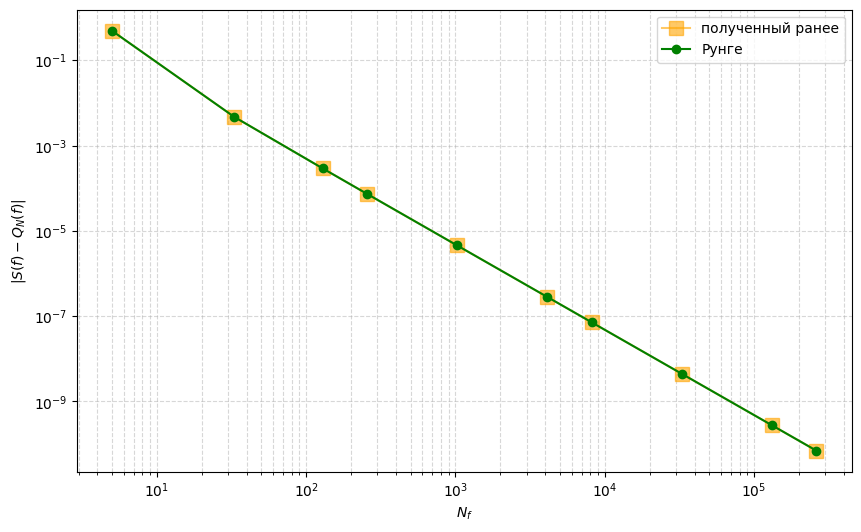

In [57]:
N_values_from_runge_algorithm = [(item[0] - 1)  for item in results_runge] # список N из алгоритма для Рунге

trapezoids_for_runge_values = composite_formula_of_trapezoids(a, b, N_values_from_runge_algorithm) # просчитываем для предыдущего алгоритма
values_trapezoids, nf_trapezoids = zip(*trapezoids_for_runge_values)
errors_trapezoids = [abs(S_f - value) for value in values_trapezoids]

nf_runge_all, error_runge_all, target_eps_all = zip(*results_runge) # для Рунге

# График
plt.figure(figsize=(10, 6))
plt.loglog(nf_trapezoids, errors_trapezoids, 's-', 
           color='orange', alpha=0.6, label='полученный ранее', markersize=10)

# Результаты самого алгоритма Рунге
plt.loglog(nf_runge_all, error_runge_all, 'o-', 
           color='green', label='Рунге', markersize=6)

plt.xlabel('$N_f$')
plt.ylabel('$|S(f) - Q_N(f)|$')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

- графики индентичны. связано с тем, что мы используем одну и ту же формулу трапеций. а основная разница в том, что -- в без-контроля-остановки мы задаем N, а в Рунге -- точность, которую хотим получить
- $N_{теор} = 44435$ и $N_{с-контролем-точности} = 8193$, что 5.4 раза меньеш. то есть -- оценка получилось сильно завышеной
- сравнивая их эффективность 
    - в алгоритме-без-контроля-точности, чтобы достичь нужной точности, мы должны
        - либо самим оценить N. Но тогда, если бы мы воспользовались нашим теоретическим предположением, то мы бы сделали в 5.4 раза больше вычислений, чем было достаточно
        - либо итерировались по значениям N_i для достижения нужной точности, а это порядка СУММА(N_i)
    - а в алгоритме с контролем точности мы останавлияемся на том моменте, когда достигли нужной точности и так же эффективно переиспользуем узлы, чтобы не делать лишних вычислений
        - но так же может быть случай, когда $N_{оптимальное}$ лежит между N и 2N, из-за чего мы можем сделать так же лишние вычисления

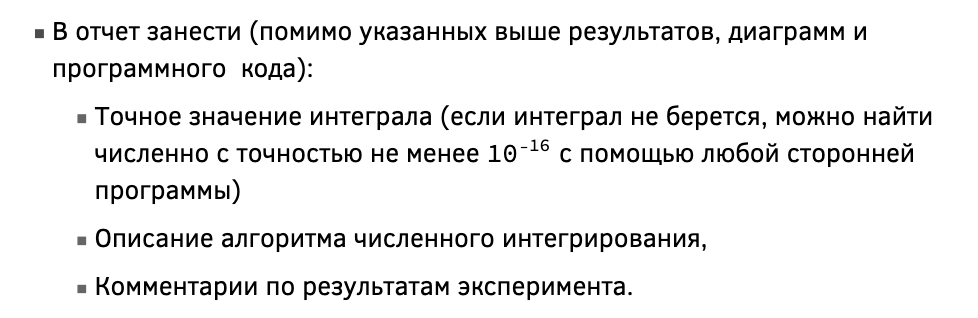

In [ ]:
print(S_f)

-0.07054363235342234
